In [2]:
# ============================================================
# 0. COMPLETE REPRODUCIBILITY SETUP
# ============================================================
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42

# Step 1: Python built-in random
random.seed(SEED)

# Step 2: OS hash seed (must be set before any Python process)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Step 3: NumPy seed
np.random.seed(SEED)

# Step 4: TensorFlow global seed
tf.random.set_seed(SEED)

# Step 5: GPU determinism — THIS IS THE KEY MISSING PIECE
os.environ['TF_DETERMINISTIC_OPS'] = '1'
os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

print("✓ All seeds fixed. Results will now be reproducible.")
print(f"  Python seed:   {SEED}")
print(f"  NumPy seed:    {SEED}")
print(f"  TF seed:       {SEED}")
print(f"  TF_DETERMINISTIC_OPS: ON")



✓ All seeds fixed. Results will now be reproducible.
  Python seed:   42
  NumPy seed:    42
  TF seed:       42
  TF_DETERMINISTIC_OPS: ON


### 1. IMPORTS

In [3]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.utils import class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Input, LSTM, Dense, Dropout, Conv1D,
    MaxPooling1D, GlobalAveragePooling1D,
    LayerNormalization, MultiHeadAttention,
    Add, Reshape
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import GlorotUniform

### 2. LOAD DATA

In [4]:
# 1. Load the datasets
df_malaysia = pd.read_csv('Malaysia 2000-01-01 to 2025-11-30.csv')
df_states = pd.read_csv('States 2000-01-01 to 2025-11-30.csv')

# 2. Convert 'datetime' safely (supports mixed formats)
df_malaysia['datetime'] = pd.to_datetime(df_malaysia['datetime'], format='mixed', dayfirst=True)
df_states['datetime'] = pd.to_datetime(df_states['datetime'], format='mixed', dayfirst=True)

# 3. Concatenate the dataframes
combined_df = pd.concat([df_malaysia, df_states], ignore_index=True)

# 4. Standardize the 'name' column
combined_df['name'] = combined_df['name'].astype(str).str.title()

# 5. Sort by name and datetime
combined_df = combined_df.sort_values(by=['name', 'datetime'])

# 6. Save the combined dataset
combined_df.to_csv('Combined_Malaysia_States_Weather_Data2.csv', index=False)

### 3. DATA PREPROCESSING

In [5]:
# 1. Load the dataset
combined_df = pd.read_csv('Combined_Malaysia_States_Weather_Data2.csv')

# --- User's Cleaning Code Start ---

# Drop 'snow' and 'snowdepth' as they are irrelevant for Malaysia (mostly 0 or NaN)
combined_df = combined_df.drop(columns=['snow', 'snowdepth'])

# Correct 'rain,snow' entry to 'rain'
# Note: In the previous turn, 'preciptype' was object.
combined_df['preciptype'] = combined_df['preciptype'].replace('rain,snow', 'rain')

# Fill missing 'preciptype' with "none"
combined_df['preciptype'] = combined_df['preciptype'].fillna('none')

# Fill missing 'severerisk' with 0
combined_df['severerisk'] = combined_df['severerisk'].fillna(0)

# Fill missing 'windgust' with the 'windspeed' value
combined_df['windgust'] = combined_df['windgust'].fillna(combined_df['windspeed'])

# 7. Impute Missing Values with Interpolation
def fill_missing_by_group(group):
    # Columns to interpolate linearly
    cols_to_interpolate = ['solarradiation', 'solarenergy', 'uvindex', 
                           'sealevelpressure', 'cloudcover', 'visibility']
    
    # Apply linear interpolation
    group[cols_to_interpolate] = group[cols_to_interpolate].interpolate(method='linear', limit_direction='both')
    return group

# Apply the imputation function grouped by location name
# Using group_keys=False to avoid MultiIndex creation if possible, or we reset index later
combined_df = combined_df.groupby('name', group_keys=False).apply(fill_missing_by_group)

# 8. Handle any remaining missing values (fallback)
cols_zero_fill = ['solarradiation', 'solarenergy', 'uvindex']
combined_df[cols_zero_fill] = combined_df[cols_zero_fill].fillna(0)

cols_mean_fill = ['sealevelpressure', 'cloudcover', 'visibility']
for col in cols_mean_fill:
    if combined_df[col].isnull().sum() > 0:
        combined_df[col] = combined_df[col].fillna(combined_df[col].mean())

# --- User's Cleaning Code End ---

# --- One-Hot Encoding Steps ---

# Select columns to encode
# We perform this AFTER the cleaning steps above
cols_to_encode = ['name', 'preciptype', 'conditions', 'icon']

# Perform one-hot encoding
# Using prefix to make column names clear (e.g., name_Johor)
# dtype=int ensures 1 and 0 instead of True/False
combined_df_encoded = pd.get_dummies(combined_df, columns=cols_to_encode, prefix=cols_to_encode, dtype=int)

# Check the result
print("Cleaned and Encoded DataFrame Info:")
print(combined_df_encoded.info())

# Save the final preprocessed data
output_filename = 'Cleaned_Encoded_Malaysia_Weather_Data2.csv'
combined_df_encoded.to_csv(output_filename, index=False)

C:\Users\user\AppData\Local\Temp\ipykernel_21284\3488208733.py:34: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  combined_df = combined_df.groupby('name', group_keys=False).apply(fill_missing_by_group)


Cleaned and Encoded DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
Index: 54585 entries, 0 to 54584
Data columns (total 47 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   datetime                                 54585 non-null  object 
 1   tempmax                                  54585 non-null  float64
 2   tempmin                                  54585 non-null  float64
 3   temp                                     54585 non-null  float64
 4   feelslikemax                             54585 non-null  float64
 5   feelslikemin                             54585 non-null  float64
 6   feelslike                                54585 non-null  float64
 7   dew                                      54585 non-null  float64
 8   humidity                                 54585 non-null  float64
 9   precip                                   54585 non-null  float64
 10  precipprob     

### 4. CORRELATION HEATMAP


Correlation with Precipitation (precip):
precip                                     1.000000
windgust                                   0.185352
name_Malaysia                              0.177936
windspeed                                  0.168744
icon_rain                                  0.147542
precipprob                                 0.147542
preciptype_rain                            0.139506
conditions_Rain, Partially cloudy          0.125970
visibility                                 0.111131
humidity                                   0.110665
precipcover                                0.109377
winddir                                    0.073571
uvindex                                    0.041386
conditions_Rain, Overcast                  0.035150
solarenergy                                0.025573
solarradiation                             0.025549
sealevelpressure                           0.015967
conditions_Snow, Rain, Partially cloudy   -0.000672
conditions_Clear      

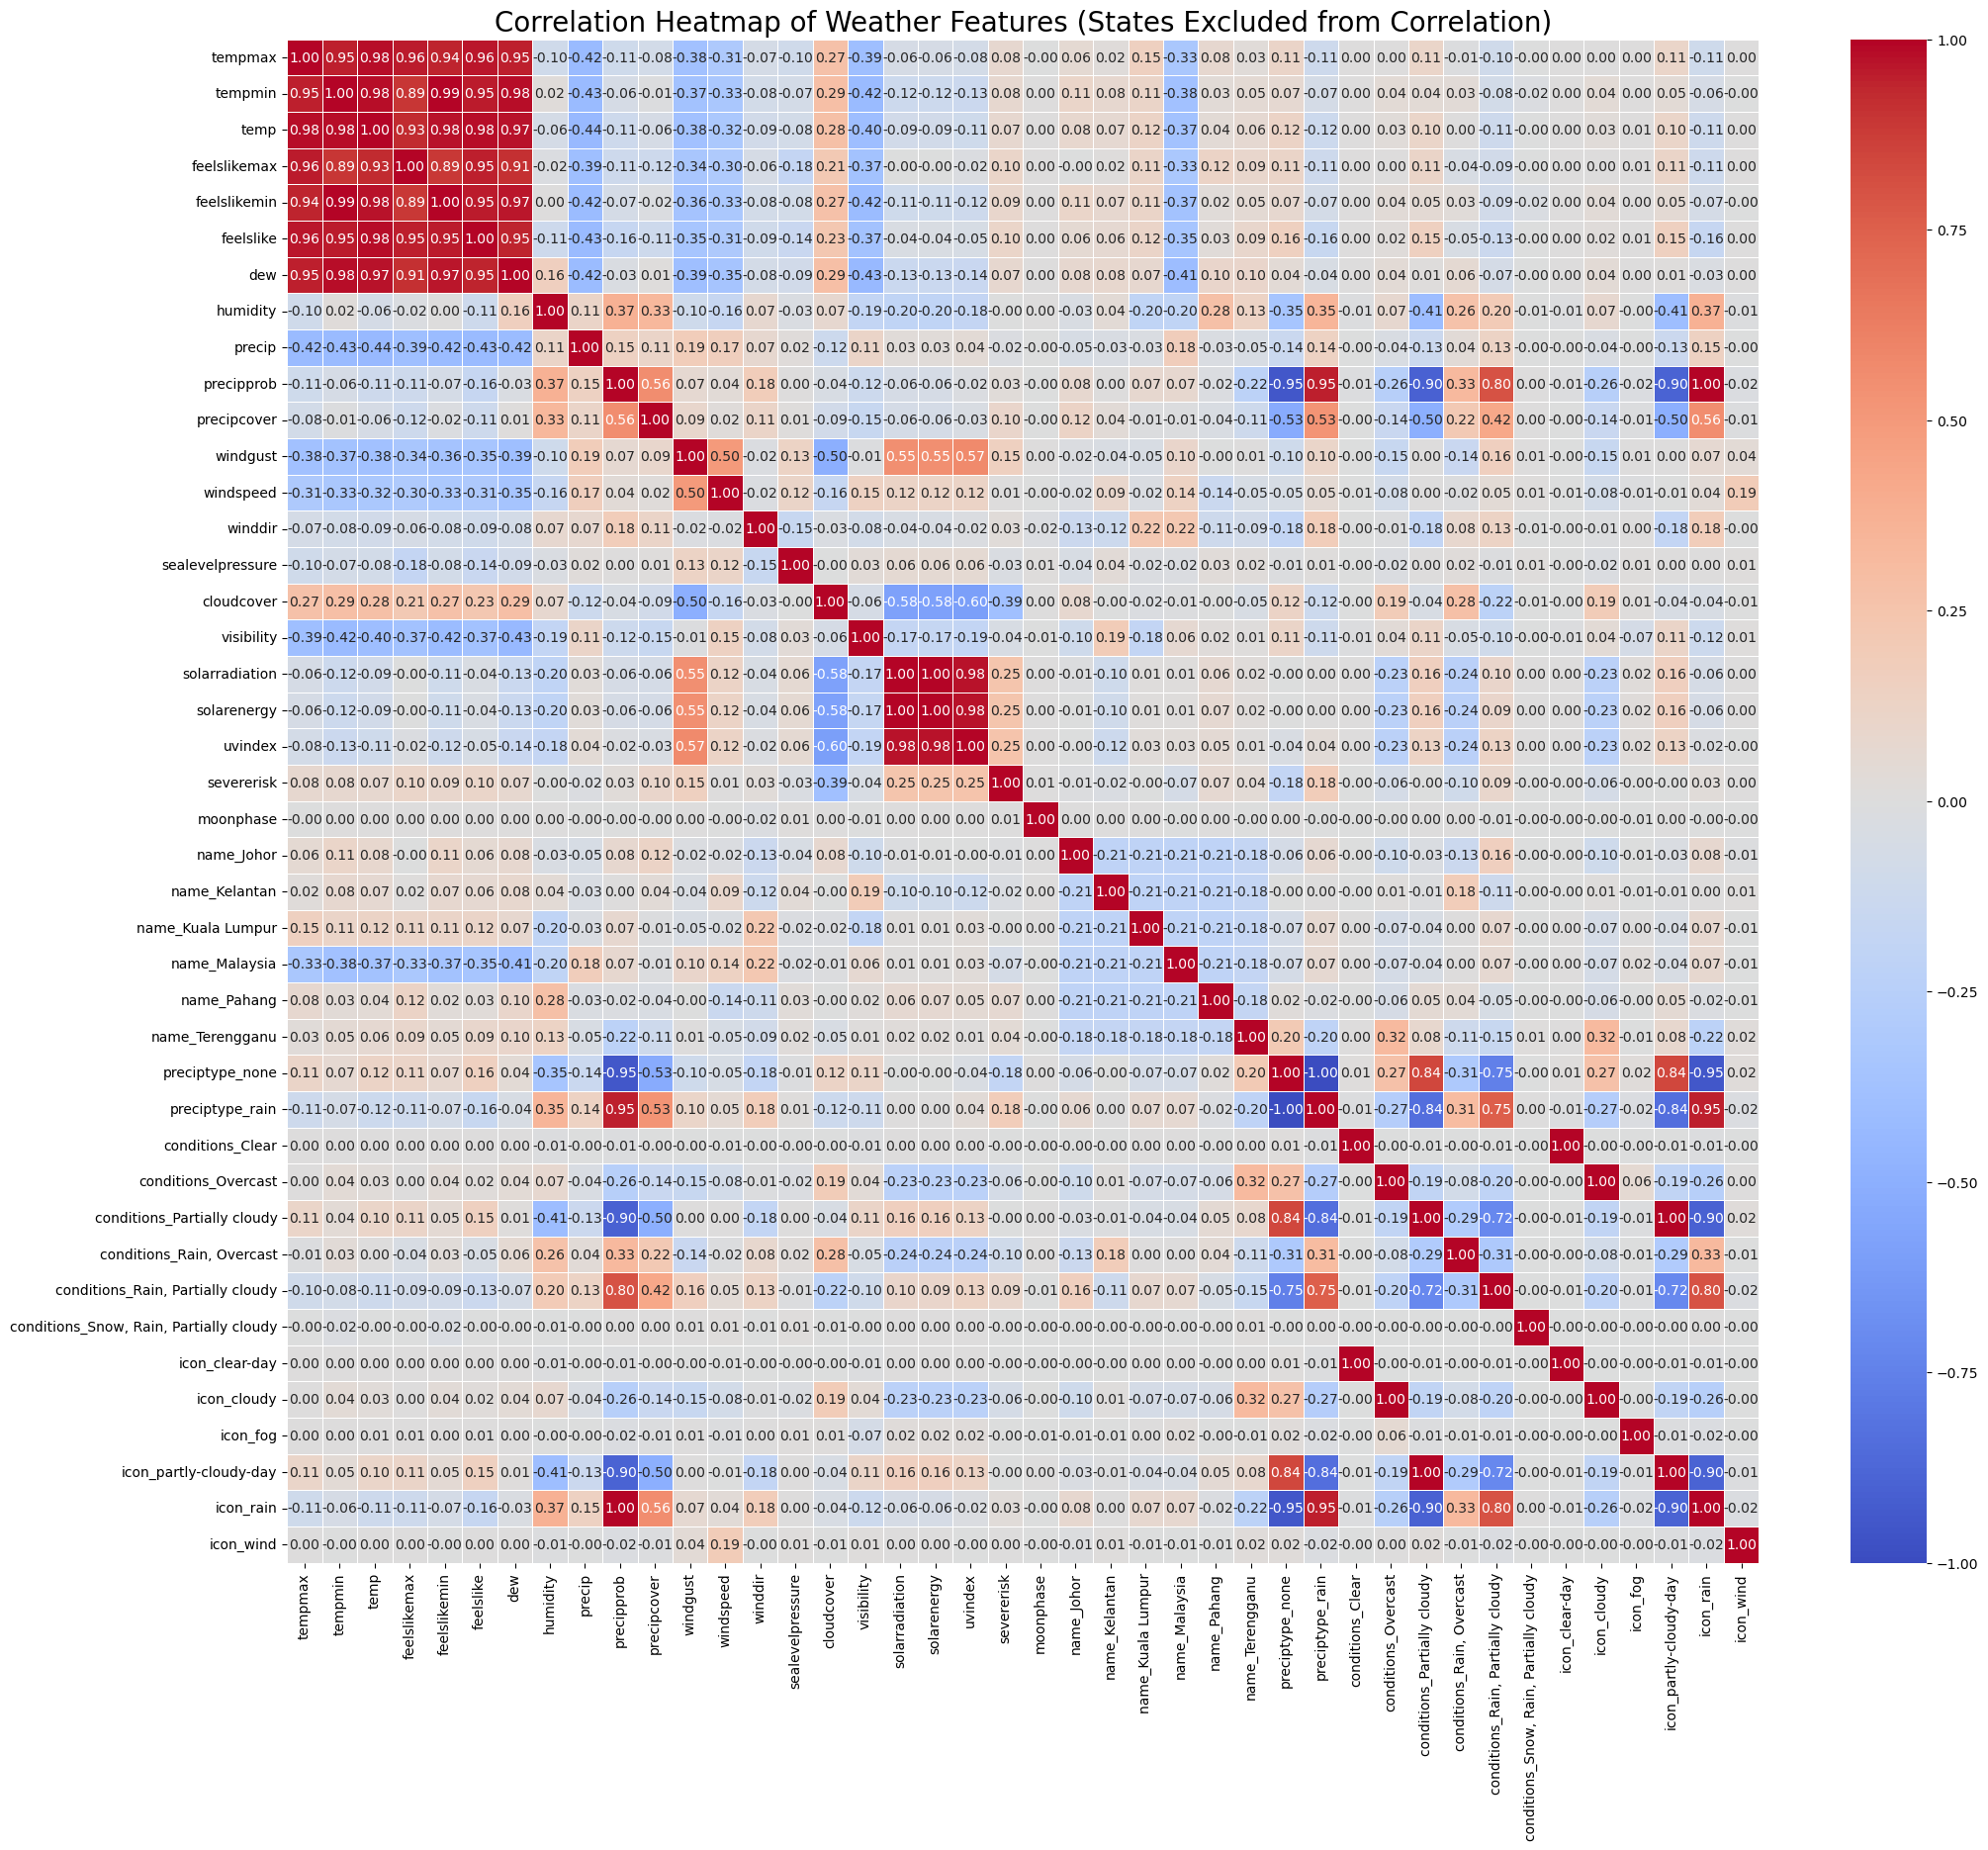

In [6]:
# Load the latest processed data (without state encoding)
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data2.csv')

# Drop non-numeric columns for correlation calculation
# 'name', 'datetime', 'sunrise', 'sunset', 'description', 'stations' are non-numeric.
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_df.corr()

# Create the heatmap
plt.figure(figsize=(24, 20))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Heatmap of Weather Features (States Excluded from Correlation)', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Get correlation with 'precip' and sort descending
precip_corr = corr_matrix['precip'].sort_values(ascending=False)

print("\nCorrelation with Precipitation (precip):")
print(precip_corr.to_string())

### 5. DEFINE FEATURES & TARGET

In [7]:
# ============================================================
# 2. LOAD DATA
# ============================================================
df = pd.read_csv('Cleaned_Encoded_Malaysia_Weather_Data2.csv')
df = df.reset_index(drop=True)
print(f"\nDataset loaded: {len(df)} rows, {df.shape[1]} columns")

FEATURE_COLS = [
    'precip',
    'visibility',
    'windspeed',
    'windgust',
    'conditions_Rain, Partially cloudy',
    'precipprob',
    'name_Malaysia',
    'icon_rain',
    'humidity',
    'preciptype_rain',
    'winddir',
    'precipcover',
    'sealevelpressure',
    'uvindex'
]

# Binary target: 1 = Heavy (>1.0mm), 0 = Not Heavy
df['target_binary'] = (df['precip'] > 1.0).astype(int)

class_counts = df['target_binary'].value_counts()
print(f"\nClass distribution:")
print(f"  Not Heavy (0): {class_counts[0]:,} days ({class_counts[0]/len(df)*100:.1f}%)")
print(f"  Heavy     (1): {class_counts[1]:,} days ({class_counts[1]/len(df)*100:.1f}%)")

features = df[FEATURE_COLS].values
target   = df['target_binary'].values


Dataset loaded: 54585 rows, 47 columns

Class distribution:
  Not Heavy (0): 49,924 days (91.5%)
  Heavy     (1): 4,661 days (8.5%)


### 5.1 Exploratory Data Analysis (EDA)


#### 1. Feature Distributions by Target Class
Let's see how important weather features differ when there is heavy rain vs when there is none.


C:\Users\user\AppData\Local\Temp\ipykernel_21284\2795233887.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binary', y='humidity', ax=axes[0], palette='Set2')
C:\Users\user\AppData\Local\Temp\ipykernel_21284\2795233887.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target_binary', y='sealevelpressure', ax=axes[1], palette='Set2')


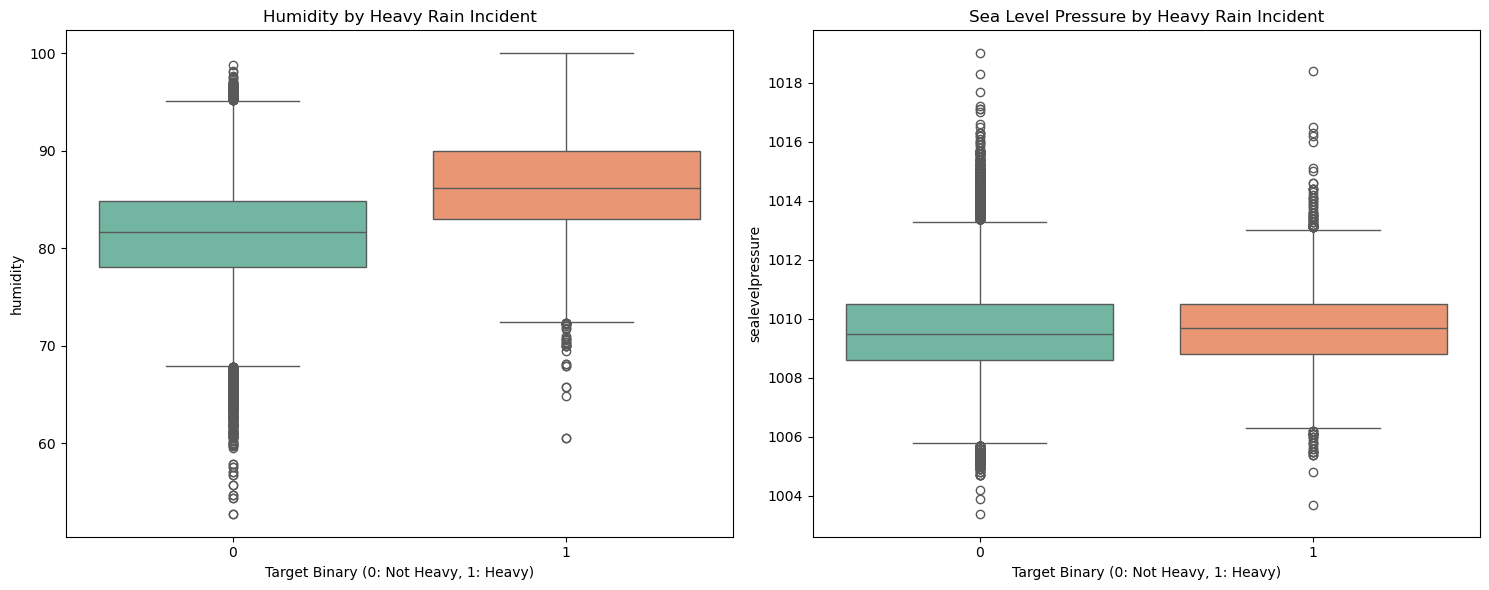

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='target_binary', y='humidity', ax=axes[0], palette='Set2')
axes[0].set_title('Humidity by Heavy Rain Incident')
axes[0].set_xlabel('Target Binary (0: Not Heavy, 1: Heavy)')

sns.boxplot(data=df, x='target_binary', y='sealevelpressure', ax=axes[1], palette='Set2')
axes[1].set_title('Sea Level Pressure by Heavy Rain Incident')
axes[1].set_xlabel('Target Binary (0: Not Heavy, 1: Heavy)')

plt.tight_layout()
plt.show()


#### 2. Temporal & Seasonal Trends
Let's observe which months experience the most heavy rain.


C:\Users\user\AppData\Local\Temp\ipykernel_21284\3404597974.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_heavy_rain, x='month', y='target_binary', palette='viridis')


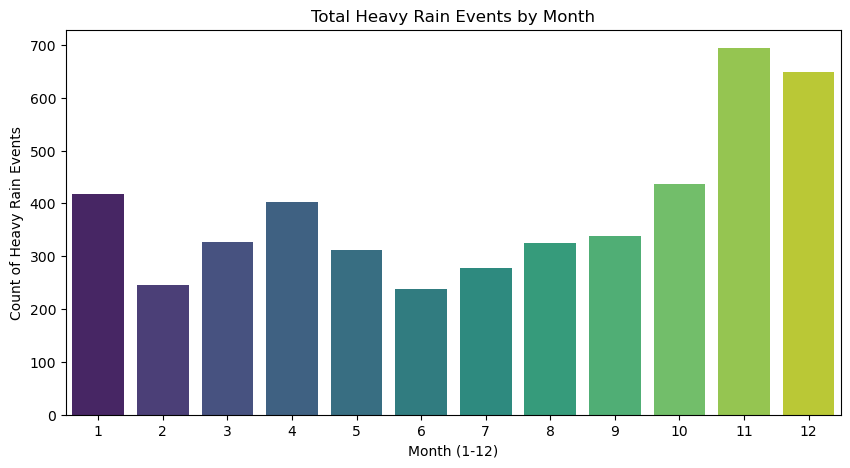

In [9]:
# Ensure datetime is parsed as datetime objects
df['datetime'] = pd.to_datetime(df['datetime'])
df['month'] = df['datetime'].dt.month

monthly_heavy_rain = df.groupby('month')['target_binary'].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_heavy_rain, x='month', y='target_binary', palette='viridis')
plt.title('Total Heavy Rain Events by Month')
plt.xlabel('Month (1-12)')
plt.ylabel('Count of Heavy Rain Events')
plt.show()


#### 3. State-wise Heavy Rain Frequency
Let's see the geographical distribution of heavy rain across the states.


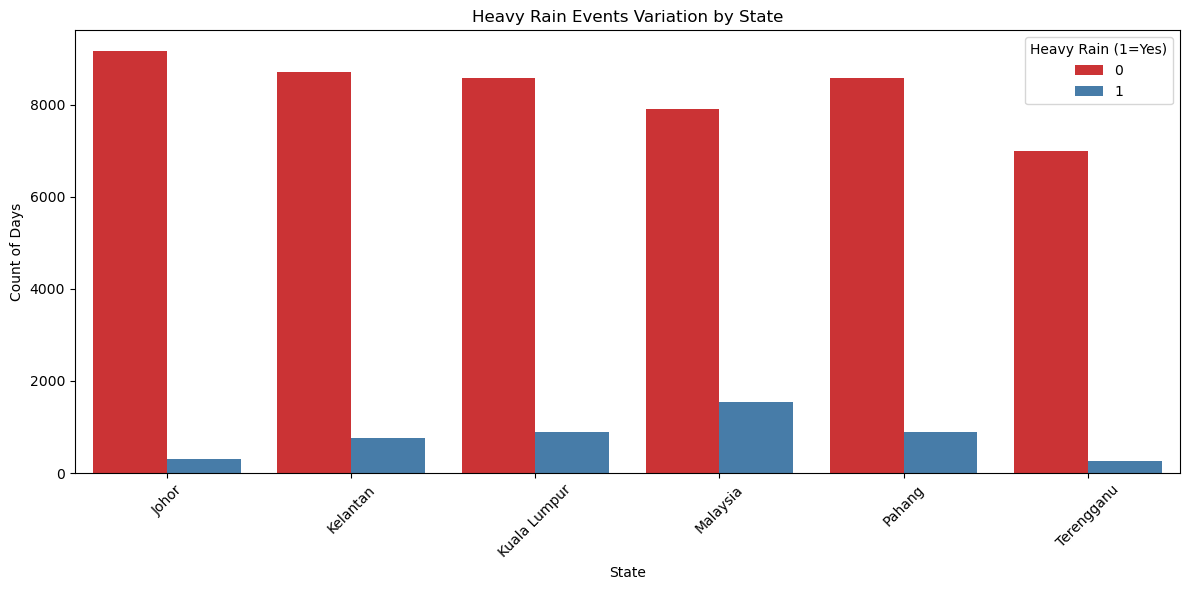

In [10]:
# Re-create the state column from the dummy variables
state_cols = [col for col in df.columns if col.startswith('name_')]
df['state'] = df[state_cols].idxmax(axis=1).str.replace('name_', '')

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='state', hue='target_binary', palette='Set1')
plt.title('Heavy Rain Events Variation by State')
plt.xlabel('State')
plt.ylabel('Count of Days')
plt.xticks(rotation=45)
plt.legend(title='Heavy Rain (1=Yes)')
plt.tight_layout()
plt.show()


#### 4. Multivariate Scatter Plot
Observing temperature against humidity, clustered by heavy rain incidents.


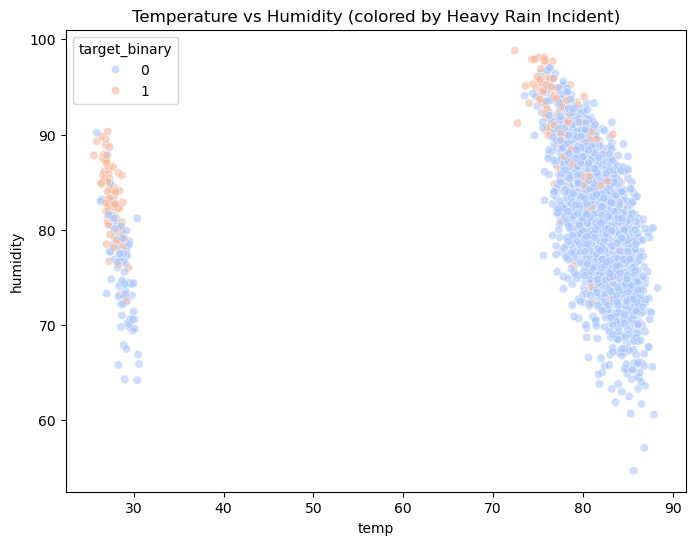

In [11]:
plt.figure(figsize=(8, 6))
# Sample the data to prevent over-plotting and slow rendering
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

sns.scatterplot(data=sample_df, x='temp', y='humidity', hue='target_binary', alpha=0.6, palette='coolwarm')
plt.title('Temperature vs Humidity (colored by Heavy Rain Incident)')
plt.show()


### 4. SHARED UTILITY FUNCTIONS

In [12]:
def set_all_seeds(seed=42):
    """Call this before every model build to guarantee reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)


def create_sequences(features, target, window_size):
    """
    Convert time-series into (X, y) sliding window sequences.
    X[i] = features[i : i+window_size]
    y[i] = target[i + window_size]  (next-day label)
    """
    X, y = [], []
    for i in range(len(features) - window_size):
        X.append(features[i : i + window_size])
        y.append(target[i + window_size])
    return np.array(X), np.array(y)


def get_class_weights(y_int):
    """Compute class weights inversely proportional to frequency."""
    weights = class_weight.compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_int),
        y=y_int
    )
    return dict(enumerate(weights))


def get_callbacks(patience_stop=15, patience_lr=7, min_lr=1e-5):
    """Return EarlyStopping + ReduceLROnPlateau callbacks."""
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=patience_stop,
        restore_best_weights=True,
        min_delta=0.001,
        verbose=0
    )
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=patience_lr,
        min_lr=min_lr,
        verbose=0
    )
    return [early_stop, reduce_lr]


def evaluate_model(model, X_test, y_test_cat, model_name="Model"):
    """Evaluate and print full classification report."""
    y_pred_prob = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test_cat, axis=1)

    acc    = accuracy_score(y_true, y_pred)
    f1_h   = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    f1_avg = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*60}")
    print(f"{model_name} — Test Results")
    print(f"{'='*60}")
    print(f"  Accuracy:          {acc:.4f}")
    print(f"  F1-Score (Heavy):  {f1_h:.4f}")
    print(f"  F1-Score (Weighted): {f1_avg:.4f}")
    print(f"\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print(f"\nClassification Report:")
    print(classification_report(
        y_true, y_pred,
        target_names=['Not Heavy', 'Heavy'],
        zero_division=0
    ))
    return acc, f1_h


def run_tscv(build_fn, param_grid, X, y_cat, n_splits=5, epochs=80,
             batch_size=32, model_name="Model"):
    """
    Run 5-fold TimeSeriesSplit cross-validation with hyperparameter search.
    Selects best params by Heavy-class F1 (primary) then accuracy.
    Returns: best_params, avg_f1, avg_acc
    """
    tscv = TimeSeriesSplit(n_splits=n_splits)
    best_params    = None
    best_avg_f1    = -np.inf
    best_avg_acc   = -np.inf

    for param_idx, params in enumerate(param_grid, 1):
        print(f"\n[{model_name}] Params {param_idx}/{len(param_grid)}: {params}")
        fold_f1s  = []
        fold_accs = []

        for fold, (train_val_idx, test_idx) in enumerate(tscv.split(X), 1):
            # ── Always re-seed before building ──
            set_all_seeds(SEED)

            X_tv = X[train_val_idx];  y_tv = y_cat[train_val_idx]
            X_te = X[test_idx];       y_te = y_cat[test_idx]

            # Temporal 80/20 split inside train_val
            v_split = int(len(X_tv) * 0.8)
            X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
            y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

            # ── Fit scaler on training fold only (no leakage) ──
            # NOTE: In this structure X is already sequences of scaled features.
            # Scaling is done per-fold in the main pipeline below.

            # Class weights
            cw = get_class_weights(np.argmax(y_tr, axis=1))

            # Build & train
            build_params = {k: v for k, v in params.items() if k != 'batch_size'}
            current_batch_size = params.get('batch_size', batch_size)
            model = build_fn(
                input_shape=(X_tr.shape[1], X_tr.shape[2]),
                **build_params
            )
            model.fit(
                X_tr, y_tr,
                epochs=epochs,
                batch_size=current_batch_size,
                validation_data=(X_va, y_va),
                class_weight=cw,
                callbacks=get_callbacks(),
                verbose=0
            )

            # Evaluate on test fold
            y_pred = np.argmax(model.predict(X_te, verbose=0), axis=1)
            y_true = np.argmax(y_te, axis=1)
            fold_f1s.append(f1_score(y_true, y_pred, pos_label=1, zero_division=0))
            fold_accs.append(accuracy_score(y_true, y_pred))

        avg_f1  = np.mean(fold_f1s)
        avg_acc = np.mean(fold_accs)
        print(f"    → Avg Heavy F1: {avg_f1:.4f} | Avg Accuracy: {avg_acc:.4f}")

        # Primary metric: Heavy F1 (not overall accuracy)
        if avg_f1 > best_avg_f1 or (avg_f1 == best_avg_f1 and avg_acc > best_avg_acc):
            best_avg_f1  = avg_f1
            best_avg_acc = avg_acc
            best_params  = params

    print(f"\nBest params: {best_params}")
    print(f"  Best Avg Heavy F1: {best_avg_f1:.4f} | Accuracy: {best_avg_acc:.4f}")
    return best_params, best_avg_f1, best_avg_acc

### 5. SCALE FEATURES — FIT ON FULL TRAINING DATA

In [13]:

# Note: For proper no-leakage CV, scaler should be fit inside each fold.
# For the FINAL model training/test split, we fit only on train+val.
# The CV function above uses pre-scaled features; see Section 9 for
# the correct per-fold scaling in the final evaluation.

scaler = MinMaxScaler()

# Determine training cutoff (80% of total for final split)
WINDOW_MAX   = 4   # max window we'll try
total_seq    = len(features) - WINDOW_MAX
train_end_idx = int(total_seq * 0.8) + WINDOW_MAX  # approx

# Fit scaler only on training portion
scaler.fit(features[:train_end_idx])
features_scaled = scaler.transform(features)

print(f"\nScaler fitted on first {train_end_idx} rows (training portion only).")




Scaler fitted on first 43668 rows (training portion only).


### 6. MODEL BUILDERS

In [14]:
def build_lstm(input_shape, lstm_units=128, lstm_layers=2,
               dropout_rate=0.3, learning_rate=0.001):
    set_all_seeds(SEED)
    init = GlorotUniform(seed=SEED)
    model = Sequential()
    for i in range(lstm_layers):
        ret_seq = (i < lstm_layers - 1)
        if i == 0:
            model.add(LSTM(lstm_units, return_sequences=ret_seq,
                           kernel_initializer=init, input_shape=input_shape))
        else:
            model.add(LSTM(lstm_units, return_sequences=ret_seq,
                           kernel_initializer=init))
        model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax', kernel_initializer=init))
    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_cnn(input_shape, filters=64, kernel_size=5,
              dense_units=64, dropout_rate=0.4, learning_rate=0.001):
    set_all_seeds(SEED)
    init       = GlorotUniform(seed=SEED)
    time_steps = input_shape[0]
    model      = Sequential()

    model.add(Conv1D(filters, kernel_size, activation='relu',
                     padding='same', kernel_initializer=init,
                     input_shape=input_shape))

    if time_steps >= 2:
        model.add(MaxPooling1D(pool_size=2))

    model.add(Conv1D(filters, kernel_size, activation='relu',
                     padding='same', kernel_initializer=init))
    model.add(GlobalAveragePooling1D())
    model.add(Dense(dense_units, activation='relu', kernel_initializer=init))
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax', kernel_initializer=init))
    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_cnn_lstm(input_shape, filters=64, kernel_size=3,
                   lstm_units=64, dense_units=32,
                   dropout_rate=0.3, learning_rate=0.001):
    set_all_seeds(SEED)
    init       = GlorotUniform(seed=SEED)
    time_steps = input_shape[0]
    model      = Sequential()

    model.add(Conv1D(filters, kernel_size, activation='relu',
                     padding='same', kernel_initializer=init,
                     input_shape=input_shape))
    model.add(Conv1D(filters, kernel_size, activation='relu',
                     padding='same', kernel_initializer=init))

    if time_steps >= 2:
        model.add(MaxPooling1D(pool_size=2))

    model.add(LSTM(lstm_units, activation='relu', kernel_initializer=init))
    model.add(Dense(dense_units, activation='relu', kernel_initializer=init))
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax', kernel_initializer=init))
    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_tcn(input_shape, filters=64, kernel_size=5,
              dilation_rates=(1, 2, 4), dropout_rate=0.3):
    set_all_seeds(SEED)
    init = GlorotUniform(seed=SEED)
    model = Sequential()
    for i, d in enumerate(dilation_rates):
        kwargs = dict(filters=filters, kernel_size=kernel_size,
                      dilation_rate=d, padding='causal',
                      activation='relu', kernel_initializer=init)
        if i == 0:
            model.add(Conv1D(**kwargs, input_shape=input_shape))
        else:
            model.add(Conv1D(**kwargs))
    model.add(GlobalAveragePooling1D())
    model.add(Dense(32, activation='relu', kernel_initializer=init))
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax', kernel_initializer=init))
    model.compile(optimizer=Adam(0.001),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def build_transformer(input_shape, num_heads=2, ff_dim=32,
                      dropout_rate=0.2, learning_rate=0.001):
    set_all_seeds(SEED)
    init = GlorotUniform(seed=SEED)
    inputs = Input(shape=input_shape)
    # Multi-head self-attention
    attn_out = MultiHeadAttention(
        num_heads=num_heads, key_dim=input_shape[-1] // num_heads,
        kernel_initializer=init
    )(inputs, inputs)
    attn_out = Add()([inputs, attn_out])
    attn_out = LayerNormalization()(attn_out)
    # Feed-forward
    ff = Dense(ff_dim, activation='relu', kernel_initializer=init)(attn_out)
    ff = Dropout(dropout_rate)(ff)
    ff = Dense(input_shape[-1], kernel_initializer=init)(ff)
    ff = Add()([attn_out, ff])
    ff = LayerNormalization()(ff)
    # Classifier head
    out = GlobalAveragePooling1D()(ff)
    out = Dense(32, activation='relu', kernel_initializer=init)(out)
    out = Dropout(dropout_rate)(out)
    out = Dense(2, activation='softmax', kernel_initializer=init)(out)
    model = Model(inputs, out)
    model.compile(optimizer=Adam(learning_rate),
                  loss='categorical_crossentropy', metrics=['accuracy'])
    return model

### 7. HYPERPARAMETER GRIDS

In [15]:
LSTM_GRID = [
    {'lstm_units': 64,  'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32},
    {'lstm_units': 64,  'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 16},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 32},
    {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 64},
]

CNN_GRID = [
    {'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64},
    {'filters': 64, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32},
    {'filters': 32, 'kernel_size': 5, 'dense_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32},
    {'filters': 32, 'kernel_size': 5, 'dense_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64},

]

CNN_LSTM_GRID = [
    {'filters': 32, 'kernel_size': 3, 'lstm_units': 32,  'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 3, 'lstm_units': 64,  'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 3, 'lstm_units': 64,  'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64},
    {'filters': 64, 'kernel_size': 5, 'lstm_units': 64,  'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 5, 'lstm_units': 64,  'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
]

TCN_GRID = [
    {'filters': 32, 'kernel_size': 3, 'dilation_rates': (1,2,4), 'dropout_rate': 0.2, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 3, 'dilation_rates': (1,2,4), 'dropout_rate': 0.3, 'batch_size': 64},
    {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1,2,4), 'dropout_rate': 0.3, 'batch_size': 32},
    {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1,2,4), 'dropout_rate': 0.3, 'batch_size': 64},
    {'filters': 96, 'kernel_size': 3, 'dilation_rates': (1,2,4,8), 'dropout_rate': 0.3, 'batch_size': 16},
    {'filters': 96, 'kernel_size': 3, 'dilation_rates': (1,2,4,8), 'dropout_rate': 0.3, 'batch_size': 32},
    {'filters': 96, 'kernel_size': 3, 'dilation_rates': (1,2,4,8), 'dropout_rate': 0.3, 'batch_size': 64},
]

TRANSFORMER_GRID = [
    {'num_heads': 2, 'ff_dim': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32},
    {'num_heads': 2, 'ff_dim': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64},
    {'num_heads': 2, 'ff_dim': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32},
    {'num_heads': 2, 'ff_dim': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64},
    {'num_heads': 4, 'ff_dim': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64},
]

WINDOW_SIZES = [3, 5, 7]

search_results = {}
final_results = {}

### Pipeline: LSTM


In [16]:
model_name = 'LSTM'
build_fn = build_lstm
param_grid = LSTM_GRID

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SEARCH: {model_name}")
print(f"{'='*70}")

best_window   = None
best_f1_all   = -np.inf
best_acc_all  = -np.inf
best_params_all = None
window_results = {}

for window in WINDOW_SIZES:
    print(f"\n  Window size = {window} days")
    X, y = create_sequences(features_scaled, target, window)
    y_cat = to_categorical(y, num_classes=2)

    if len(X) < 100:
        print(f"  Not enough samples, skipping.")
        continue

    cv_split = int(len(X) * 0.8)
    best_p, best_f1, best_acc = run_tscv(
        build_fn, param_grid, X[:cv_split], y_cat[:cv_split],
        model_name=model_name
    )
    window_results[window] = {
        'params': best_p, 'f1': best_f1, 'acc': best_acc
    }

    if best_f1 > best_f1_all:
        best_f1_all    = best_f1
        best_acc_all   = best_acc
        best_window    = window
        best_params_all = best_p

search_results[model_name] = {
    'best_window': best_window,
    'best_params': best_params_all,
    'best_f1':     best_f1_all,
    'best_acc':    best_acc_all,
    'window_results': window_results
}

print(f"\n  ★ Best window: {best_window} | Params: {best_params_all}")
print(f"  ★ Best CV Heavy F1: {best_f1_all:.4f} | Accuracy: {best_acc_all:.4f}")

print(f"\n{'='*70}")
print(f"FINAL MODEL TRAINING: {model_name}")
print(f"{'='*70}")

cfg    = search_results[model_name]
window = cfg['best_window']
params = cfg['best_params']

if window is not None:
    # Create sequences
    X_all, y_all = create_sequences(features_scaled, target, window)

    # Chronological 80/20 split
    split = int(len(X_all) * 0.8)
    X_tv, X_te = X_all[:split], X_all[split:]
    y_tv, y_te = y_all[:split], y_all[split:]

    # Inner 80/20 split for val
    v_split = int(len(X_tv) * 0.8)
    X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
    y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

    print(f"  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

    # One-hot encode
    y_tr_cat = to_categorical(y_tr, 2)
    y_va_cat = to_categorical(y_va, 2)
    y_te_cat = to_categorical(y_te, 2)

    # Class weights (from training data only)
    cw = get_class_weights(y_tr)
    print(f"  Class weights: {cw}")

    # Build model — always re-seed immediately before build
    set_all_seeds(SEED)
    build_params = {k: v for k, v in params.items() if k != 'batch_size'}
    current_batch_size = params.get('batch_size', 32)
    model = build_fn(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        **build_params
    )

    # Train
    history = model.fit(
        X_tr, y_tr_cat,
        epochs=150,
        batch_size=current_batch_size,
        validation_data=(X_va, y_va_cat),
        class_weight=cw,
        callbacks=get_callbacks(patience_stop=15, patience_lr=7),
        verbose=1
    )

    # Evaluate
    acc, f1_h = evaluate_model(model, X_te, y_te_cat, model_name)
    final_results[model_name] = {
        'accuracy': acc, 'f1_heavy': f1_h,
        'window': window, 'params': params,
        'model': model, 'history': history
    }
else:
    print(f"  Skipped — no valid window found.")




CROSS-VALIDATION SEARCH: LSTM

  Window size = 3 days

[LSTM] Params 1/7: {'lstm_units': 64, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argumen

    → Avg Heavy F1: 0.2280 | Avg Accuracy: 0.6537

[LSTM] Params 2/7: {'lstm_units': 64, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argumen

    → Avg Heavy F1: 0.2303 | Avg Accuracy: 0.6668

[LSTM] Params 3/7: {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}


...

    → Avg Heavy F1: 0.2289 | Avg Accuracy: 0.6482

[LSTM] Params 7/7: {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argumen

    → Avg Heavy F1: 0.2066 | Avg Accuracy: 0.7087

Best params: {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}
  Best Avg Heavy F1: 0.2323 | Accuracy: 0.6944

  ★ Best window: 3 | Params: {'lstm_units': 128, 'lstm_layers': 2, 'dropout_rate': 0.2, 'learning_rate': 0.0005, 'batch_size': 32}
  ★ Best CV Heavy F1: 0.2347 | Accuracy: 0.6331

FINAL MODEL TRAINING: LSTM
  Train: 34932 | Val: 8733 | Test: 10917
  Class weights: {0: np.float64(0.5397571000339937), 1: np.float64(6.788184998056743)}
Epoch 1/150


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.4801 - loss: 0.6762 - val_accuracy: 0.5993 - val_loss: 0.6459 - learning_rate: 5.0000e-04
Epoch 2/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5463 - loss: 0.6621 - val_accuracy: 0.6054 - val_loss: 0.6301 - learning_rate: 5.0000e-04
Epoch 3/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5506 - loss: 0.6576 - val_accuracy: 0.6111 - val_loss: 0.6278 - learning_rate: 5.0000e-04
Epoch 4/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5544 - loss: 0.6540 - val_accuracy: 0.6196 - val_loss: 0.6219 - learning_rate: 5.0000e-04
Epoch 5/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5625 - loss: 0.6532 - val_accuracy: 0.6214 - val_loss: 0.6224 - learning_rate: 5.0000e-04
Epoch 6/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.5670 - loss: 0.6504 - val_accuracy: 0.6346 - val_loss: 0.6122 - learning_rate: 5.0000e-04
Epoch 7/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - 

### Pipeline: 1D-CNN


In [17]:
model_name = '1D-CNN'
build_fn = build_cnn
param_grid = CNN_GRID

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SEARCH: {model_name}")
print(f"{'='*70}")

best_window   = None
best_f1_all   = -np.inf
best_acc_all  = -np.inf
best_params_all = None
window_results = {}

for window in WINDOW_SIZES:
    print(f"\n  Window size = {window} days")
    X, y = create_sequences(features_scaled, target, window)
    y_cat = to_categorical(y, num_classes=2)

    if len(X) < 100:
        print(f"  Not enough samples, skipping.")
        continue

    cv_split = int(len(X) * 0.8)
    best_p, best_f1, best_acc = run_tscv(
        build_fn, param_grid, X[:cv_split], y_cat[:cv_split],
        model_name=model_name
    )
    window_results[window] = {
        'params': best_p, 'f1': best_f1, 'acc': best_acc
    }

    if best_f1 > best_f1_all:
        best_f1_all    = best_f1
        best_acc_all   = best_acc
        best_window    = window
        best_params_all = best_p

search_results[model_name] = {
    'best_window': best_window,
    'best_params': best_params_all,
    'best_f1':     best_f1_all,
    'best_acc':    best_acc_all,
    'window_results': window_results
}

print(f"\n  ★ Best window: {best_window} | Params: {best_params_all}")
print(f"  ★ Best CV Heavy F1: {best_f1_all:.4f} | Accuracy: {best_acc_all:.4f}")

print(f"\n{'='*70}")
print(f"FINAL MODEL TRAINING: {model_name}")
print(f"{'='*70}")

cfg    = search_results[model_name]
window = cfg['best_window']
params = cfg['best_params']

if window is not None:
    # Create sequences
    X_all, y_all = create_sequences(features_scaled, target, window)

    # Chronological 80/20 split
    split = int(len(X_all) * 0.8)
    X_tv, X_te = X_all[:split], X_all[split:]
    y_tv, y_te = y_all[:split], y_all[split:]

    # Inner 80/20 split for val
    v_split = int(len(X_tv) * 0.8)
    X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
    y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

    print(f"  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

    # One-hot encode
    y_tr_cat = to_categorical(y_tr, 2)
    y_va_cat = to_categorical(y_va, 2)
    y_te_cat = to_categorical(y_te, 2)

    # Class weights (from training data only)
    cw = get_class_weights(y_tr)
    print(f"  Class weights: {cw}")

    # Build model — always re-seed immediately before build
    set_all_seeds(SEED)
    build_params = {k: v for k, v in params.items() if k != 'batch_size'}
    current_batch_size = params.get('batch_size', 32)
    model = build_fn(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        **build_params
    )

    # Train
    history = model.fit(
        X_tr, y_tr_cat,
        epochs=150,
        batch_size=current_batch_size,
        validation_data=(X_va, y_va_cat),
        class_weight=cw,
        callbacks=get_callbacks(patience_stop=15, patience_lr=7),
        verbose=1
    )

    # Evaluate
    acc, f1_h = evaluate_model(model, X_te, y_te_cat, model_name)
    final_results[model_name] = {
        'accuracy': acc, 'f1_heavy': f1_h,
        'window': window, 'params': params,
        'model': model, 'history': history
    }
else:
    print(f"  Skipped — no valid window found.")




CROSS-VALIDATION SEARCH: 1D-CNN

  Window size = 3 days

[1D-CNN] Params 1/5: {'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2282 | Avg Accuracy: 0.6669

[1D-CNN] Params 2/5: {'filters': 64, 'kernel_size': 5, 'dense_units': 64, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2226 | Avg Accuracy: 0.6480

[1D-CNN] Params 3/5: {'filters': 64, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}


...

    → Avg Heavy F1: 0.2218 | Avg Accuracy: 0.7079

[1D-CNN] Params 5/5: {'filters': 32, 'kernel_size': 5, 'dense_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.1963 | Avg Accuracy: 0.7733

Best params: {'filters': 64, 'kernel_size': 3, 'dense_units': 64, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}
  Best Avg Heavy F1: 0.2279 | Accuracy: 0.7546

  ★ Best window: 3 | Params: {'filters': 32, 'kernel_size': 5, 'dense_units': 32, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'batch_size': 32}
  ★ Best CV Heavy F1: 0.2333 | Accuracy: 0.6551

FINAL MODEL TRAINING: 1D-CNN
  Train: 34932 | Val: 8733 | Test: 10917
  Class weights: {0: np.float64(0.5397571000339937), 1: np.float64(6.788184998056743)}
Epoch 1/150


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.5018 - loss: 0.6799 - val_accuracy: 0.5437 - val_loss: 0.6343 - learning_rate: 0.0010
Epoch 2/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5109 - loss: 0.6637 - val_accuracy: 0.5915 - val_loss: 0.6511 - learning_rate: 0.0010
Epoch 3/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5520 - loss: 0.6569 - val_accuracy: 0.5976 - val_loss: 0.6541 - learning_rate: 0.0010
Epoch 4/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5782 - loss: 0.6571 - val_accuracy: 0.5749 - val_loss: 0.6489 - learning_rate: 0.0010
Epoch 5/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5836 - loss: 0.6524 - val_accuracy: 0.5950 - val_loss: 0.6344 - learning_rate: 0.0010
Epoch 6/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5911 - loss: 0.6522 - val_accuracy: 0.6170 - val_loss: 0.6354 - learning_rate: 0.0010
Epoch 7/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.5769 - loss: 

### Pipeline: CNN-LSTM


In [18]:
model_name = 'CNN-LSTM'
build_fn = build_cnn_lstm
param_grid = CNN_LSTM_GRID

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SEARCH: {model_name}")
print(f"{'='*70}")

best_window   = None
best_f1_all   = -np.inf
best_acc_all  = -np.inf
best_params_all = None
window_results = {}

for window in WINDOW_SIZES:
    print(f"\n  Window size = {window} days")
    X, y = create_sequences(features_scaled, target, window)
    y_cat = to_categorical(y, num_classes=2)

    if len(X) < 100:
        print(f"  Not enough samples, skipping.")
        continue

    cv_split = int(len(X) * 0.8)
    best_p, best_f1, best_acc = run_tscv(
        build_fn, param_grid, X[:cv_split], y_cat[:cv_split],
        model_name=model_name
    )
    window_results[window] = {
        'params': best_p, 'f1': best_f1, 'acc': best_acc
    }

    if best_f1 > best_f1_all:
        best_f1_all    = best_f1
        best_acc_all   = best_acc
        best_window    = window
        best_params_all = best_p

search_results[model_name] = {
    'best_window': best_window,
    'best_params': best_params_all,
    'best_f1':     best_f1_all,
    'best_acc':    best_acc_all,
    'window_results': window_results
}

print(f"\n  ★ Best window: {best_window} | Params: {best_params_all}")
print(f"  ★ Best CV Heavy F1: {best_f1_all:.4f} | Accuracy: {best_acc_all:.4f}")

print(f"\n{'='*70}")
print(f"FINAL MODEL TRAINING: {model_name}")
print(f"{'='*70}")

cfg    = search_results[model_name]
window = cfg['best_window']
params = cfg['best_params']

if window is not None:
    # Create sequences
    X_all, y_all = create_sequences(features_scaled, target, window)

    # Chronological 80/20 split
    split = int(len(X_all) * 0.8)
    X_tv, X_te = X_all[:split], X_all[split:]
    y_tv, y_te = y_all[:split], y_all[split:]

    # Inner 80/20 split for val
    v_split = int(len(X_tv) * 0.8)
    X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
    y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

    print(f"  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

    # One-hot encode
    y_tr_cat = to_categorical(y_tr, 2)
    y_va_cat = to_categorical(y_va, 2)
    y_te_cat = to_categorical(y_te, 2)

    # Class weights (from training data only)
    cw = get_class_weights(y_tr)
    print(f"  Class weights: {cw}")

    # Build model — always re-seed immediately before build
    set_all_seeds(SEED)
    build_params = {k: v for k, v in params.items() if k != 'batch_size'}
    current_batch_size = params.get('batch_size', 32)
    model = build_fn(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        **build_params
    )

    # Train
    history = model.fit(
        X_tr, y_tr_cat,
        epochs=150,
        batch_size=current_batch_size,
        validation_data=(X_va, y_va_cat),
        class_weight=cw,
        callbacks=get_callbacks(patience_stop=15, patience_lr=7),
        verbose=1
    )

    # Evaluate
    acc, f1_h = evaluate_model(model, X_te, y_te_cat, model_name)
    final_results[model_name] = {
        'accuracy': acc, 'f1_heavy': f1_h,
        'window': window, 'params': params,
        'model': model, 'history': history
    }
else:
    print(f"  Skipped — no valid window found.")




CROSS-VALIDATION SEARCH: CNN-LSTM

  Window size = 3 days

[CNN-LSTM] Params 1/5: {'filters': 32, 'kernel_size': 3, 'lstm_units': 32, 'dense_units': 16, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2283 | Avg Accuracy: 0.6398

[CNN-LSTM] Params 2/5: {'filters': 64, 'kernel_size': 3, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 32}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2286 | Avg Accuracy: 0.6062

[CNN-LSTM] Params 3/5: {'filters': 64, 'kernel_size': 3, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.001, 'batch_size': 64}


...

    → Avg Heavy F1: 0.2252 | Avg Accuracy: 0.7767

[CNN-LSTM] Params 5/5: {'filters': 64, 'kernel_size': 5, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2212 | Avg Accuracy: 0.7317

Best params: {'filters': 64, 'kernel_size': 5, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 32}
  Best Avg Heavy F1: 0.2252 | Accuracy: 0.7767

  ★ Best window: 3 | Params: {'filters': 64, 'kernel_size': 5, 'lstm_units': 64, 'dense_units': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
  ★ Best CV Heavy F1: 0.2341 | Accuracy: 0.6522

FINAL MODEL TRAINING: CNN-LSTM
  Train: 34932 | Val: 8733 | Test: 10917
  Class weights: {0: np.float64(0.5397571000339937), 1: np.float64(6.788184998056743)}
Epoch 1/150


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


546/546 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.4982 - loss: 0.6803 - val_accuracy: 0.5772 - val_loss: 0.6415 - learning_rate: 5.0000e-04
Epoch 2/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5371 - loss: 0.6603 - val_accuracy: 0.6475 - val_loss: 0.6180 - learning_rate: 5.0000e-04
Epoch 3/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5704 - loss: 0.6522 - val_accuracy: 0.6437 - val_loss: 0.6229 - learning_rate: 5.0000e-04
Epoch 4/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5880 - loss: 0.6491 - val_accuracy: 0.6772 - val_loss: 0.6095 - learning_rate: 5.0000e-04
Epoch 5/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6029 - loss: 0.6487 - val_accuracy: 0.6608 - val_loss: 0.6238 - learning_rate: 5.0000e-04
Epoch 6/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6118 - loss: 0.6440 - val_accuracy: 0.6692 - val_loss: 0.6198 - learning_rate: 5.0000e-04
Epoch 7/150
546/546 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.620

### Pipeline: TCN


In [19]:
model_name = 'TCN'
build_fn = build_tcn
param_grid = TCN_GRID

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SEARCH: {model_name}")
print(f"{'='*70}")

best_window   = None
best_f1_all   = -np.inf
best_acc_all  = -np.inf
best_params_all = None
window_results = {}

for window in WINDOW_SIZES:
    print(f"\n  Window size = {window} days")
    X, y = create_sequences(features_scaled, target, window)
    y_cat = to_categorical(y, num_classes=2)

    if len(X) < 100:
        print(f"  Not enough samples, skipping.")
        continue

    cv_split = int(len(X) * 0.8)
    best_p, best_f1, best_acc = run_tscv(
        build_fn, param_grid, X[:cv_split], y_cat[:cv_split],
        model_name=model_name
    )
    window_results[window] = {
        'params': best_p, 'f1': best_f1, 'acc': best_acc
    }

    if best_f1 > best_f1_all:
        best_f1_all    = best_f1
        best_acc_all   = best_acc
        best_window    = window
        best_params_all = best_p

search_results[model_name] = {
    'best_window': best_window,
    'best_params': best_params_all,
    'best_f1':     best_f1_all,
    'best_acc':    best_acc_all,
    'window_results': window_results
}

print(f"\n  ★ Best window: {best_window} | Params: {best_params_all}")
print(f"  ★ Best CV Heavy F1: {best_f1_all:.4f} | Accuracy: {best_acc_all:.4f}")

print(f"\n{'='*70}")
print(f"FINAL MODEL TRAINING: {model_name}")
print(f"{'='*70}")

cfg    = search_results[model_name]
window = cfg['best_window']
params = cfg['best_params']

if window is not None:
    # Create sequences
    X_all, y_all = create_sequences(features_scaled, target, window)

    # Chronological 80/20 split
    split = int(len(X_all) * 0.8)
    X_tv, X_te = X_all[:split], X_all[split:]
    y_tv, y_te = y_all[:split], y_all[split:]

    # Inner 80/20 split for val
    v_split = int(len(X_tv) * 0.8)
    X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
    y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

    print(f"  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

    # One-hot encode
    y_tr_cat = to_categorical(y_tr, 2)
    y_va_cat = to_categorical(y_va, 2)
    y_te_cat = to_categorical(y_te, 2)

    # Class weights (from training data only)
    cw = get_class_weights(y_tr)
    print(f"  Class weights: {cw}")

    # Build model — always re-seed immediately before build
    set_all_seeds(SEED)
    build_params = {k: v for k, v in params.items() if k != 'batch_size'}
    current_batch_size = params.get('batch_size', 32)
    model = build_fn(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        **build_params
    )

    # Train
    history = model.fit(
        X_tr, y_tr_cat,
        epochs=150,
        batch_size=current_batch_size,
        validation_data=(X_va, y_va_cat),
        class_weight=cw,
        callbacks=get_callbacks(patience_stop=15, patience_lr=7),
        verbose=1
    )

    # Evaluate
    acc, f1_h = evaluate_model(model, X_te, y_te_cat, model_name)
    final_results[model_name] = {
        'accuracy': acc, 'f1_heavy': f1_h,
        'window': window, 'params': params,
        'model': model, 'history': history
    }
else:
    print(f"  Skipped — no valid window found.")




CROSS-VALIDATION SEARCH: TCN

  Window size = 3 days

[TCN] Params 1/7: {'filters': 32, 'kernel_size': 3, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.2, 'batch_size': 32}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2164 | Avg Accuracy: 0.6256

[TCN] Params 2/7: {'filters': 64, 'kernel_size': 3, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2287 | Avg Accuracy: 0.6325

[TCN] Params 3/7: {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3, 'batch_size': 32}


...

    → Avg Heavy F1: 0.2306 | Avg Accuracy: 0.7110

[TCN] Params 7/7: {'filters': 96, 'kernel_size': 3, 'dilation_rates': (1, 2, 4, 8), 'dropout_rate': 0.3, 'batch_size': 64}


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_reg

    → Avg Heavy F1: 0.2136 | Avg Accuracy: 0.7318

Best params: {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3, 'batch_size': 32}
  Best Avg Heavy F1: 0.2326 | Accuracy: 0.7208

  ★ Best window: 7 | Params: {'filters': 64, 'kernel_size': 5, 'dilation_rates': (1, 2, 4), 'dropout_rate': 0.3, 'batch_size': 32}
  ★ Best CV Heavy F1: 0.2326 | Accuracy: 0.7208

FINAL MODEL TRAINING: TCN
  Train: 34929 | Val: 8733 | Test: 10916
  Class weights: {0: np.float64(0.5397274244390877), 1: np.float64(6.792882147024504)}
Epoch 1/150


c:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.5800 - loss: 0.6742 - val_accuracy: 0.5668 - val_loss: 0.6689 - learning_rate: 0.0010
Epoch 2/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5445 - loss: 0.6532 - val_accuracy: 0.5527 - val_loss: 0.6737 - learning_rate: 0.0010
Epoch 3/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5533 - loss: 0.6465 - val_accuracy: 0.5297 - val_loss: 0.6749 - learning_rate: 0.0010
Epoch 4/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5572 - loss: 0.6423 - val_accuracy: 0.5763 - val_loss: 0.6726 - learning_rate: 0.0010
Epoch 5/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.5941 - loss: 0.6394 - val_accuracy: 0.5020 - val_loss: 0.7306 - learning_rate: 0.0010
Epoch 6/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5946 - loss: 0.6361 - val_accuracy: 0.5286 - val_loss: 0.7228 - learning_rate: 0.0010
Epoch 7/150
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6062 - loss: 

### Pipeline: Transformer


In [20]:
model_name = 'Transformer'
build_fn = build_transformer
param_grid = TRANSFORMER_GRID

print(f"\n{'='*70}")
print(f"CROSS-VALIDATION SEARCH: {model_name}")
print(f"{'='*70}")

best_window   = None
best_f1_all   = -np.inf
best_acc_all  = -np.inf
best_params_all = None
window_results = {}

for window in WINDOW_SIZES:
    print(f"\n  Window size = {window} days")
    X, y = create_sequences(features_scaled, target, window)
    y_cat = to_categorical(y, num_classes=2)

    if len(X) < 100:
        print(f"  Not enough samples, skipping.")
        continue

    cv_split = int(len(X) * 0.8)
    best_p, best_f1, best_acc = run_tscv(
        build_fn, param_grid, X[:cv_split], y_cat[:cv_split],
        model_name=model_name
    )
    window_results[window] = {
        'params': best_p, 'f1': best_f1, 'acc': best_acc
    }

    if best_f1 > best_f1_all:
        best_f1_all    = best_f1
        best_acc_all   = best_acc
        best_window    = window
        best_params_all = best_p

search_results[model_name] = {
    'best_window': best_window,
    'best_params': best_params_all,
    'best_f1':     best_f1_all,
    'best_acc':    best_acc_all,
    'window_results': window_results
}

print(f"\n  ★ Best window: {best_window} | Params: {best_params_all}")
print(f"  ★ Best CV Heavy F1: {best_f1_all:.4f} | Accuracy: {best_acc_all:.4f}")

print(f"\n{'='*70}")
print(f"FINAL MODEL TRAINING: {model_name}")
print(f"{'='*70}")

cfg    = search_results[model_name]
window = cfg['best_window']
params = cfg['best_params']

if window is not None:
    # Create sequences
    X_all, y_all = create_sequences(features_scaled, target, window)

    # Chronological 80/20 split
    split = int(len(X_all) * 0.8)
    X_tv, X_te = X_all[:split], X_all[split:]
    y_tv, y_te = y_all[:split], y_all[split:]

    # Inner 80/20 split for val
    v_split = int(len(X_tv) * 0.8)
    X_tr, X_va = X_tv[:v_split], X_tv[v_split:]
    y_tr, y_va = y_tv[:v_split], y_tv[v_split:]

    print(f"  Train: {len(X_tr)} | Val: {len(X_va)} | Test: {len(X_te)}")

    # One-hot encode
    y_tr_cat = to_categorical(y_tr, 2)
    y_va_cat = to_categorical(y_va, 2)
    y_te_cat = to_categorical(y_te, 2)

    # Class weights (from training data only)
    cw = get_class_weights(y_tr)
    print(f"  Class weights: {cw}")

    # Build model — always re-seed immediately before build
    set_all_seeds(SEED)
    build_params = {k: v for k, v in params.items() if k != 'batch_size'}
    current_batch_size = params.get('batch_size', 32)
    model = build_fn(
        input_shape=(X_tr.shape[1], X_tr.shape[2]),
        **build_params
    )

    # Train
    history = model.fit(
        X_tr, y_tr_cat,
        epochs=150,
        batch_size=current_batch_size,
        validation_data=(X_va, y_va_cat),
        class_weight=cw,
        callbacks=get_callbacks(patience_stop=15, patience_lr=7),
        verbose=1
    )

    # Evaluate
    acc, f1_h = evaluate_model(model, X_te, y_te_cat, model_name)
    final_results[model_name] = {
        'accuracy': acc, 'f1_heavy': f1_h,
        'window': window, 'params': params,
        'model': model, 'history': history
    }
else:
    print(f"  Skipped — no valid window found.")




CROSS-VALIDATION SEARCH: Transformer

  Window size = 3 days

[Transformer] Params 1/5: {'num_heads': 2, 'ff_dim': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
    → Avg Heavy F1: 0.2138 | Avg Accuracy: 0.6131

[Transformer] Params 2/5: {'num_heads': 2, 'ff_dim': 32, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
    → Avg Heavy F1: 0.2214 | Avg Accuracy: 0.5639

[Transformer] Params 3/5: {'num_heads': 2, 'ff_dim': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 32}
    → Avg Heavy F1: 0.1887 | Avg Accuracy: 0.6710

[Transformer] Params 4/5: {'num_heads': 2, 'ff_dim': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001, 'batch_size': 64}
    → Avg Heavy F1: 0.1930 | Avg Accuracy: 0.6987

[Transformer] Params 5/5: {'num_heads': 4, 'ff_dim': 32, 'dropout_rate': 0.3, 'learning_rate': 0.0005, 'batch_size': 64}
    → Avg Heavy F1: 0.2109 | Avg Accuracy: 0.6009

Best params: {'num_heads': 2, 'ff_dim': 32, 'dropout_rate': 0.2, 'learning_rate':

### 10. RANDOM FOREST BASELINE

In [21]:

print(f"\n{'='*70}")
print("RANDOM FOREST BASELINE")
print(f"{'='*70}")

# Use same window as CNN-LSTM for fair comparison
# Find best model so far based on accuracy
best_acc = -1
best_model_name = 'LSTM'
for m_name, res in final_results.items():
    if res['accuracy'] > best_acc:
        best_acc = res['accuracy']
        best_model_name = m_name

rf_window = search_results.get(best_model_name, {}).get('best_window', 2)
X_rf, y_rf = create_sequences(features_scaled, target, rf_window)
X_rf_flat = X_rf.reshape(X_rf.shape[0], -1)

split = int(len(X_rf_flat) * 0.8)
X_tv_rf, X_te_rf = X_rf_flat[:split], X_rf_flat[split:]
y_tv_rf, y_te_rf = y_rf[:split],      y_rf[split:]

rf = RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=-1)
param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2']
}
rf_search = RandomizedSearchCV(
    rf, param_dist, n_iter=15, scoring='f1',  # use F1 not accuracy
    cv=TimeSeriesSplit(n_splits=5), n_jobs=-1,
    verbose=1, random_state=SEED
)
rf_search.fit(X_tv_rf, y_tv_rf)

best_rf   = rf_search.best_estimator_
y_pred_rf = best_rf.predict(X_te_rf)
rf_acc    = accuracy_score(y_te_rf, y_pred_rf)
rf_f1     = f1_score(y_te_rf, y_pred_rf, pos_label=1, zero_division=0)

print(f"\nBest RF params: {rf_search.best_params_}")
print(f"RF Test Accuracy:  {rf_acc:.4f}")
print(f"RF Heavy F1-score: {rf_f1:.4f}")
print("\nClassification Report (Random Forest):")
print(classification_report(y_te_rf, y_pred_rf,
      target_names=['Not Heavy', 'Heavy'], zero_division=0))

final_results['Random Forest'] = {
    'accuracy': rf_acc, 'f1_heavy': rf_f1,
    'window': rf_window, 'params': rf_search.best_params_
}


RANDOM FOREST BASELINE
Fitting 5 folds for each of 15 candidates, totalling 75 fits

Best RF params: {'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20}
RF Test Accuracy:  0.9471
RF Heavy F1-score: 0.1502

Classification Report (Random Forest):
              precision    recall  f1-score   support

   Not Heavy       0.95      1.00      0.97     10334
       Heavy       0.53      0.09      0.15       583

    accuracy                           0.95     10917
   macro avg       0.74      0.54      0.56     10917
weighted avg       0.93      0.95      0.93     10917



### 11. FINAL COMPARISON TABLE

In [22]:
print(f"\n{'='*70}")
print("FINAL MODEL COMPARISON — TABLE 1")
print(f"{'='*70}")
print(f"{'Model':<20} {'Accuracy':>10} {'F1 (Heavy)':>12} {'Window':>8}")
print("-" * 55)

# Identify the model with highest accuracy across all final results EXCLUDING Random Forest
best_dl_acc = -1
best_dl_model = None
for m_name, res in final_results.items():
    if m_name in search_results and res['accuracy'] > best_dl_acc:
        best_dl_acc = res['accuracy']
        best_dl_model = m_name

for name, res in final_results.items():
    marker = " ★" if name == best_dl_model else ""
    print(f"{name+marker:<22} {res['accuracy']:>9.4f} {res['f1_heavy']:>12.4f} {res['window']:>8}")


FINAL MODEL COMPARISON — TABLE 1
Model                  Accuracy   F1 (Heavy)   Window
-------------------------------------------------------
LSTM                      0.7992       0.2194        3
1D-CNN                    0.8330       0.2298        3
CNN-LSTM                  0.8229       0.1757        3
TCN                       0.8008       0.2350        7
Transformer ★             0.8973       0.2055        3
Random Forest             0.9471       0.1502        3


### 12. 60-DAY ROLLING FORECAST WITH BEST MODEL

In [29]:
# Select the best Deep Learning model automatically based on test accuracy
best_dl_acc = -1
best_dl_model = None

for m_name in search_results.keys():
    if m_name in final_results and final_results[m_name]['accuracy'] > best_dl_acc:
        best_dl_acc = final_results[m_name]['accuracy']
        best_dl_model = m_name

# For the generic title, use the real overall best (which could be Random Forest) but forecast uses DL model
best_overall_acc = -1
best_overall_model = None
for m_name, res in final_results.items():
    if res['accuracy'] > best_overall_acc:
        best_overall_acc = res['accuracy']
        best_overall_model = m_name


print(f"\n{'='*70}")
print("60-DAY ROLLING FORECAST")
print(f"{'='*70}")

best_cfg    = search_results[best_dl_model]
best_window = best_cfg['best_window']
best_params = best_cfg['best_params']

X_fc, y_fc = create_sequences(features_scaled, target, best_window)
train_cut   = len(X_fc) - 60

X_tr_fc = X_fc[:train_cut];  y_tr_fc = y_fc[:train_cut]
X_forecast   = X_fc[train_cut:];  y_forecast   = y_fc[train_cut:]

y_tr_fc_cat = to_categorical(y_tr_fc, 2)
cw_fc = get_class_weights(y_tr_fc)

set_all_seeds(SEED)
# Get the build function dynamically
build_func_map = {
    "LSTM": build_lstm,
    "1D-CNN": build_cnn,
    "CNN-LSTM": build_cnn_lstm,
    "TCN": build_tcn,
    "Transformer": build_transformer
}
# Remove params that are not part of model architecture
model_params = {k: v for k, v in best_params.items() if k != 'batch_size'}

fc_model = build_func_map[best_dl_model](
    input_shape=(X_tr_fc.shape[1], X_tr_fc.shape[2]),
    **model_params
)
fc_model.fit(
    X_tr_fc, y_tr_fc_cat,
    epochs=100,
    batch_size=best_params.get('batch_size', 32),
    class_weight=cw_fc,
    verbose=0
)

y_forecast_prob = fc_model.predict(X_forecast, verbose=0)
y_forecast_pred = np.argmax(y_forecast_prob, axis=1)

fc_acc = accuracy_score(y_forecast, y_forecast_pred)
fc_f1  = f1_score(y_forecast, y_forecast_pred, pos_label=1, zero_division=0)

print(f"\n60-Day Forecast Accuracy:  {fc_acc:.4f}")
print(f"60-Day Heavy F1-score:     {fc_f1:.4f}")
print("\nClassification Report (60-Day Forecast):")
print(classification_report(y_forecast, y_forecast_pred,
      target_names=['Not Heavy', 'Heavy'], zero_division=0))



60-DAY ROLLING FORECAST



60-Day Forecast Accuracy:  0.7833
60-Day Heavy F1-score:     0.5517

Classification Report (60-Day Forecast):
              precision    recall  f1-score   support

   Not Heavy       0.95      0.78      0.86        50
       Heavy       0.42      0.80      0.55        10

    accuracy                           0.78        60
   macro avg       0.69      0.79      0.70        60
weighted avg       0.86      0.78      0.81        60



### 13. TRAINING CURVE PLOT

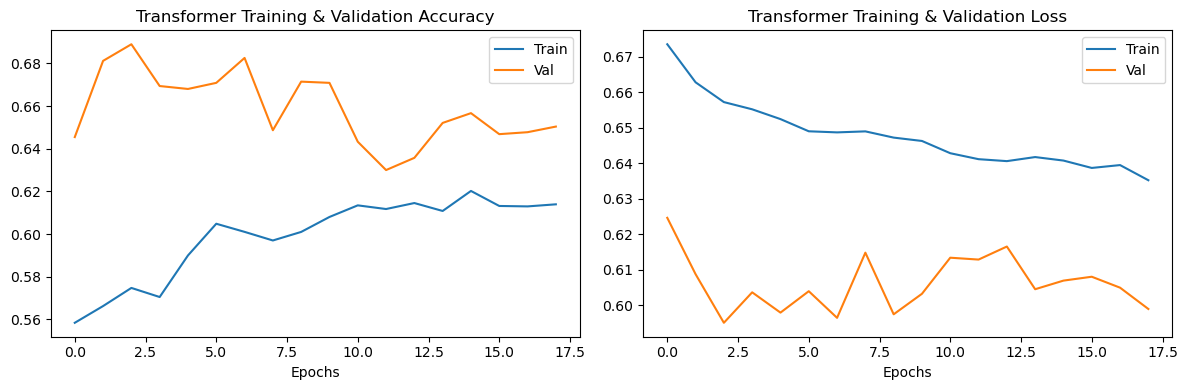


Training curves saved to transformer_training_curves.png


In [24]:

history = final_results[best_dl_model]['history']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'],    label='Train')
axes[0].plot(history.history['val_accuracy'],label='Val')
axes[0].set_title(f'{best_dl_model} Training & Validation Accuracy')
axes[0].set_xlabel('Epochs'); axes[0].legend()

axes[1].plot(history.history['loss'],    label='Train')
axes[1].plot(history.history['val_loss'],label='Val')
axes[1].set_title(f'{best_dl_model} Training & Validation Loss')
axes[1].set_xlabel('Epochs'); axes[1].legend()

plt.tight_layout()
plt.savefig(f'{best_dl_model.lower().replace("-", "_")}_training_curves.png', dpi=150)
plt.show()
print(f"\nTraining curves saved to {best_dl_model.lower().replace('-', '_')}_training_curves.png")


### 14. TARGET VARIABLE DISTRIBUTION ANALYSIS

C:\Users\user\AppData\Local\Temp\ipykernel_21284\3734234476.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='target_binary', ax=axes[1], palette='viridis')


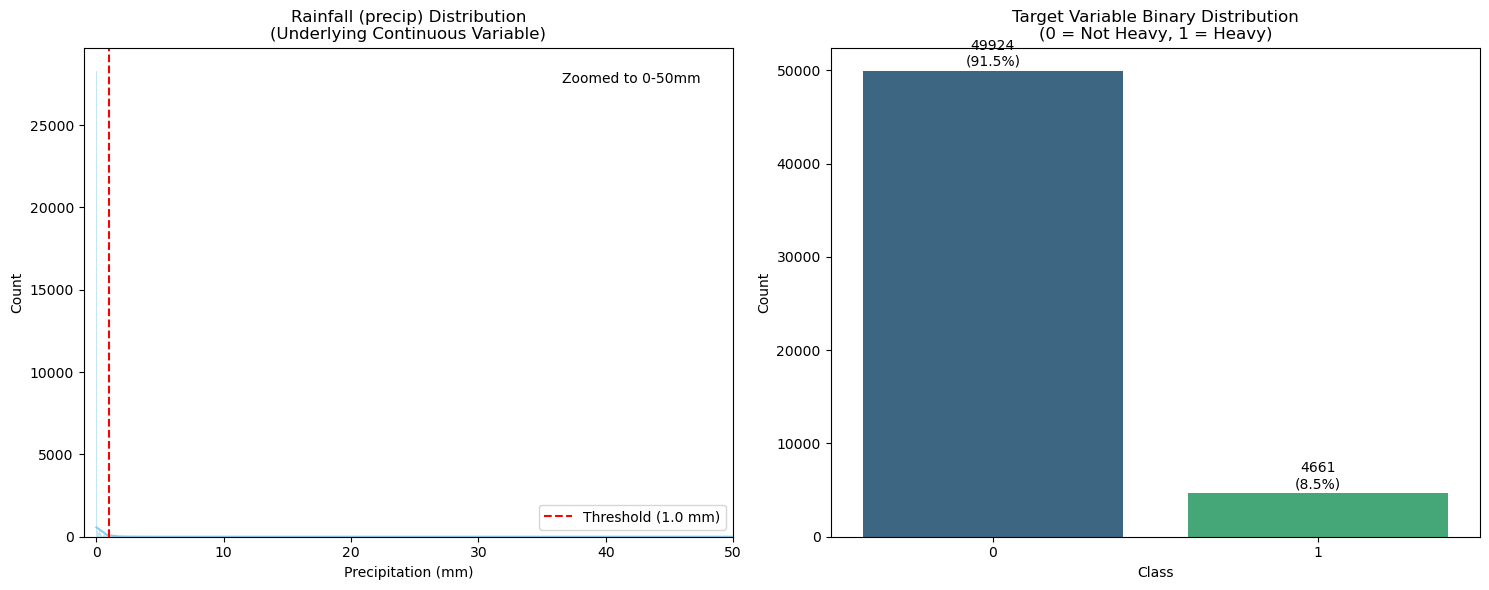

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

total = len(df)
percentage = class_counts / total * 100

# Setup plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Continuous Distribution
sns.histplot(data=df, x='precip', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Rainfall (precip) Distribution\n(Underlying Continuous Variable)')
axes[0].set_xlabel('Precipitation (mm)')
axes[0].axvline(x=1.0, color='r', linestyle='--', label='Threshold (1.0 mm)')

if df['precip'].max() > 50:
    axes[0].set_xlim(-1, 50) 
    axes[0].text(0.95, 0.95, 'Zoomed to 0-50mm', transform=axes[0].transAxes, ha='right', va='top')
axes[0].legend()

# Plot 2: Target Binary Distribution
sns.countplot(data=df, x='target_binary', ax=axes[1], palette='viridis')
axes[1].set_title('Target Variable Binary Distribution\n(0 = Not Heavy, 1 = Heavy)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

for i, count in enumerate(class_counts):
    axes[1].text(i, count + (total*0.01), f'{count}\n({percentage[i]:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

### 15. FINAL TEST ACCURACY COMPARISON

C:\Users\user\AppData\Local\Temp\ipykernel_21284\2144311248.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Model', y='Test Accuracy', data=df_acc, palette='viridis')


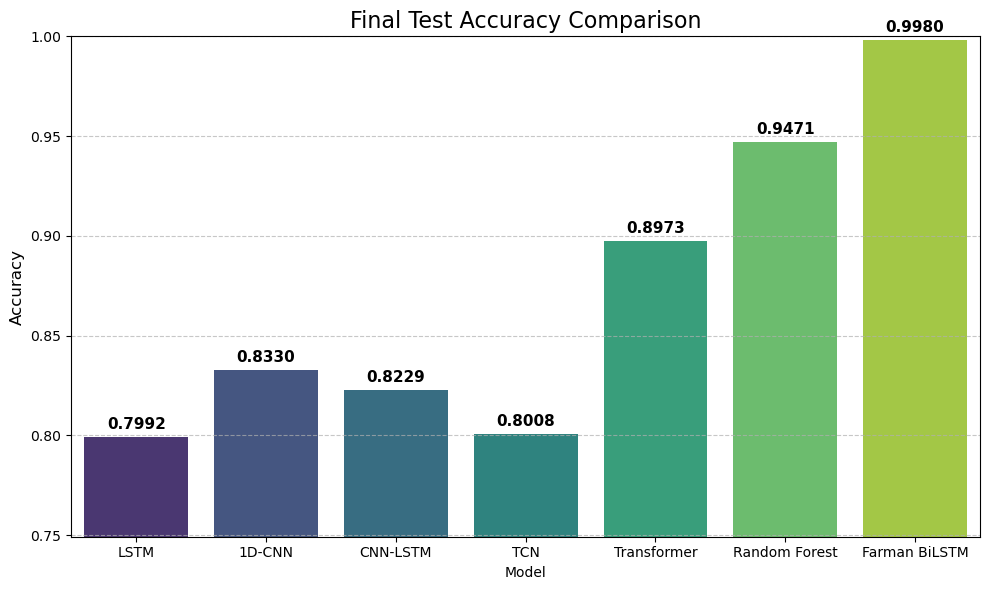

In [26]:
# Extract data dynamically from final_results
models = list(final_results.keys())
accuracies = [res['accuracy'] for res in final_results.values()]

# Add Farman's work for final comparison
models.append('Farman BiLSTM')
accuracies.append(0.9980)

df_acc = pd.DataFrame({
    'Model': models,
    'Test Accuracy': accuracies
})

plt.figure(figsize=(10, 6))
ax = sns.barplot(x='Model', y='Test Accuracy', data=df_acc, palette='viridis')

plt.title('Final Test Accuracy Comparison', fontsize=16)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(min(accuracies) - 0.05, 1.00)  
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value annotations on top of bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points', 
                fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 16. EXPORT WEB APP ASSETS
Save the final trained network and scaling mechanisms for physical deployment to the Flask Backend framework.

In [27]:
import joblib
fc_model.save('flood_model.h5')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(FEATURE_COLS, 'features.pkl')
print("Model, Scaler, and Features successfully exported for Web App!")

Model, Scaler, and Features successfully exported for Web App!
